# Imports

Inferring actions from visual observations requires distinguishing changes caused by an agent’s behavior from changes arising from the surrounding scene. Although consecutive frames contain evidence of motion, they do not directly reveal the action that produced it. This makes action inference challenging when appearance, object configuration, and environmental dynamics vary across observations.

In this work, we investigate whether motion embeddings can provide a useful representation for inferring actions from image sequences. Our central hypothesis is that explicitly representing changes in an agent’s spatial configuration can support action prediction while reducing reliance on incidental visual features. This perspective connects visual representation learning with inverse dynamics: recovering the action associated with an observed transition.

We study this question in LunarLander, using a controlled setting to examine the relationship between visual motion and discrete actions. Our objective is to assess what information motion embeddings preserve about the underlying behavior and where visual ambiguity limits action recovery. More broadly, this work explores motion-based representations as a step toward learning behavior from visual observations.

In [1]:
import json
import os
from pathlib import Path

import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

from IPython.display import Image as DisplayImage, Video, display
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

/Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths

In [5]:
Path.cwd().parent

PosixPath('/Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference')

In [44]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

LUNAR_EXPERT_VIDEO_DIR = PROJECT_ROOT / "lunarlander_expert" / "videos" / "expert_pretrain"

ARTIFACTS_DIR = NOTEBOOKS_DIR / "artifacts"
PRETRAIN_DIR  = ARTIFACTS_DIR / "lunarlander_pretrain"

CONTROL_POINTS_DIR    = PRETRAIN_DIR / "control_points"
BACKGROUND_POINTS_DIR = PRETRAIN_DIR / "background_points"
ACTION_EMBEDDINGS_DIR = PRETRAIN_DIR / "action_embeddings"

TOKENS_DIR = PRETRAIN_DIR / "tokens"
PLOTS_DIR  = PRETRAIN_DIR / "plots"
MODELS_DIR = PRETRAIN_DIR / "models"
LOGS_DIR   = PRETRAIN_DIR / "logs"
GENERATED_VIDEO_DIR = PLOTS_DIR / "videos"

CONTROL_POINTS_PLOTS_DIR = PLOTS_DIR / "control_points"
CONTROL_POINTS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

N_PRETRAIN_VIDEOS = 500
MAX_FRAMES_PER_EPISODE = 80

for path in [
    ARTIFACTS_DIR,
    PRETRAIN_DIR,
    CONTROL_POINTS_DIR,
    BACKGROUND_POINTS_DIR,
    ACTION_EMBEDDINGS_DIR,
    TOKENS_DIR,
    PLOTS_DIR,
    MODELS_DIR,
    LOGS_DIR,
    GENERATED_VIDEO_DIR
]:

    path.mkdir(parents=True, exist_ok=True)

lunar_video_paths = sorted(LUNAR_EXPERT_VIDEO_DIR.glob("*.mp4"))[:N_PRETRAIN_VIDEOS]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LUNAR_EXPERT_VIDEO_DIR:", LUNAR_EXPERT_VIDEO_DIR)
print("num lunar videos:", len(lunar_video_paths))
print("PRETRAIN_DIR:",PRETRAIN_DIR)

if len(lunar_video_paths) == 0:
    raise FileNotFoundError(
        f"No Lunar Lander expert videos found in {LUNAR_EXPERT_VIDEO_DIR}. "
        "Generate or move .mp4 files there first."
    )

PROJECT_ROOT: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference
LUNAR_EXPERT_VIDEO_DIR: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/lunarlander_expert/videos/expert_pretrain
num lunar videos: 500
PRETRAIN_DIR: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain


In [45]:
# Video helpers

def read_video(path, max_frames=None, stride=1, start_frame=0):
    cap = cv2.VideoCapture(str(path))

    if start_frame:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    frames_out = []
    frame_no = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_no % stride == 0:
            frames_out.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            if max_frames is not None and len(frames_out) >= max_frames:
                break

        frame_no += 1

    cap.release()

    if not frames_out:
        raise RuntimeError(f"No frames read from {path}")

    return np.stack(frames_out)


def sample_even_frame_indices(num_frames, max_frames):
    if num_frames <= 0:
        return np.asarray([], dtype=int)

    if max_frames is None or num_frames <= max_frames:
        return np.arange(num_frames, dtype=int)

    return np.unique(
        np.linspace(0, num_frames - 1, int(max_frames), dtype=int)
    )


def read_video_even(path, max_frames=None, stride=1, return_indices=False):
    full_frames = read_video(path, max_frames=None, stride=stride)
    frame_indices = sample_even_frame_indices(len(full_frames), max_frames)
    frames = full_frames[frame_indices]

    if return_indices:
        return frames, frame_indices * stride

    return frames


def video_frame_count(path):
    return len(read_video(path, max_frames=None, stride=1))


def clip_indices(num_frames, clip_frames=48, seed=0):
    if num_frames <= 0:
        return np.asarray([], dtype=int)

    clip_frames = min(int(clip_frames), int(num_frames))
    rng = np.random.default_rng(seed)

    max_start = max(0, int(num_frames) - clip_frames)
    start = int(rng.integers(0, max_start + 1)) if max_start else 0

    return np.arange(start, start + clip_frames, dtype=int)


def save_video(frames, path, fps=30):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frames = frames.astype(np.uint8)
    imageio.mimsave(path, frames, fps=fps)
    return path


def show_video(frames, name, fps=30, embed=True):
    path = save_video(frames, GENERATED_VIDEO_DIR / name, fps=fps)
    display(Video(str(path), embed=embed, html_attributes="controls muted loop"))
    return path


def show_video_file(path, embed=True):
    path = Path(path)
    display(Video(str(path), embed=embed, html_attributes="controls muted loop"))
    return path

def save_control_points_plot(fig, name):
    for extension in ("png", "pdf"):
        output_path = CONTROL_POINTS_PLOTS_DIR / f"{name}.{extension}"
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print("saved:", output_path)

# LunarLander Videos

To generate the video dataset, we use a policy trained in the LunarLander environment to collect \(N\) episodes, recording each episode as a sequence of rendered frames. The resulting videos capture the agent’s behavior and the corresponding visual changes throughout each trajectory, providing the observations used in our motion-embedding and action-inference experiments.

In [ ]:
# Lunar Lander expert videos

random_video_path = np.random.choice(lunar_video_paths)
random_video_frames = read_video(random_video_path)

print("num lunar expert videos:", len(lunar_video_paths))
print("random video:", random_video_path)
print("random video frames:", random_video_frames.shape)

show_video_file(random_video_path, embed=True)

num lunar expert videos: 500
random video: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-359.mp4
random video frames: (205, 400, 600, 3)


PosixPath('/Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-359.mp4')

# Data

## Control Points

For the current experiments, we use environment-specific heuristics to generate object masks and control points from LunarLander videos. We define control points as a sparse set of spatial landmarks that summarize the object’s position and geometry, providing the inputs for subsequent motion representation learning. In our implementation, these comprise the mask centroid and selected boundary extrema. They are geometric descriptors rather than guaranteed correspondences to fixed physical locations on the object.

The intended pipeline consists of object segmentation followed by control-point extraction from the resulting mask. However, developing and evaluating a general-purpose segmentation method is outside the scope of the present experiments. LunarLander’s simple visual structure allows us to use color and geometry heuristics as a practical data-generation mechanism, focusing our investigation on motion embeddings and action inference. This simplification makes the current evaluation environment-specific; extending the approach to more complex scenes will require assessing the effects of segmentation errors and control-point consistency.

### Heuristic

In [29]:
# Control Points - Model

CONTROL_POINT_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]


def mask_to_record(mask, object_id):
    ys, xs = np.nonzero(mask)

    if len(xs) == 0:
        return None

    x1, x2 = int(xs.min()), int(xs.max()) + 1
    y1, y2 = int(ys.min()), int(ys.max()) + 1

    return {
        "object_id": object_id,
        "mask": mask,
        "box": (x1, y1, x2, y2),
        "area": int(mask.sum()),
        "centroid": (float(xs.mean()), float(ys.mean())),
    }


def largest_connected_component(mask, min_area=30):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8),
        connectivity=8,
    )

    if num_labels <= 1:
        return np.zeros_like(mask, dtype=bool)

    areas = stats[1:, cv2.CC_STAT_AREA]
    best = int(np.argmax(areas)) + 1

    if areas[best - 1] < min_area:
        return np.zeros_like(mask, dtype=bool)

    return labels == best


def lunar_lander_agent_records(frame):
    rgb = frame.astype(np.int16)
    red = rgb[:, :, 0]
    green = rgb[:, :, 1]
    blue = rgb[:, :, 2]
    brightness = rgb.mean(axis=2)
    colorfulness = np.max(rgb, axis=2) - np.min(rgb, axis=2)

    h, w = frame.shape[:2]
    yy, xx = np.indices((h, w))

    scene_window = (
        (yy < int(h * 0.82))
        & (xx > int(w * 0.12))
        & (xx < int(w * 0.88))
    )

    white_terrain = (red > 180) & (green > 180) & (blue > 180) & (colorfulness < 45)
    yellow_flags = (red > 150) & (green > 120) & (blue < 100)

    lander_body = (
        (blue > 100)
        & (red > 50)
        & (green > 45)
        & (blue > red + 15)
        & (blue > green + 10)
    )

    lander_legs = (
        (blue > 70)
        & (green > 55)
        & (red < 150)
        & (colorfulness > 25)
    )

    thruster_flame = (
        (red > 130)
        & (green < 130)
        & (blue < 170)
        & (brightness > 45)
    )

    mask = (
        scene_window
        & ~white_terrain
        & ~yellow_flags
        & (lander_body | lander_legs | thruster_flame)
    )

    mask = cv2.morphologyEx(
        mask.astype(np.uint8),
        cv2.MORPH_CLOSE,
        np.ones((5, 5), dtype=np.uint8),
        iterations=1,
    ).astype(bool)

    mask = largest_connected_component(mask, min_area=20)
    record = mask_to_record(mask, 0)

    if record is None:
        return []

    record.update(
        {
            "class_id": -101,
            "class_name": "lunar_lander_agent",
            "confidence": 1.0,
            "source": "env_specific_color_geometry",
        }
    )

    return [record]


def active_agent_records(frame, model=None, conf_min=0.25, max_objects=40, scene_type="lunar_lander"):
    if scene_type == "lunar_lander":
        return lunar_lander_agent_records(frame)

    raise ValueError(f"Unsupported scene_type: {scene_type}")


def render_active_agents_inverse_background(frame, records, title=None, alpha_bg=0.35, alpha_agent=0.55):
    active_mask = np.zeros(frame.shape[:2], dtype=bool)

    for record in records:
        active_mask |= record["mask"]

    bg_mask = ~active_mask
    image = frame.copy()

    image[bg_mask] = (
        image[bg_mask] * (1 - alpha_bg)
        + np.array([40, 180, 90]) * alpha_bg
    ).astype(np.uint8)

    image[active_mask] = (
        image[active_mask] * (1 - alpha_agent)
        + np.array([230, 50, 40]) * alpha_agent
    ).astype(np.uint8)

    return image, bg_mask, active_mask


def control_points_from_record(record):
    mask = record["mask"]
    ys, xs = np.nonzero(mask)

    if len(xs) == 0:
        return []

    x1, y1, x2, y2 = record["box"]
    centroid_x, centroid_y = record["centroid"]

    front_idx = np.argmin(xs)
    back_idx = np.argmax(xs)
    left_idx = np.argmax(ys)
    right_idx = np.argmin(ys)
    contact_idx = np.argmax(ys)

    points = [
        ("centroid", centroid_x, centroid_y),
        ("axis_front", float(xs[front_idx]), float(ys[front_idx])),
        ("axis_back", float(xs[back_idx]), float(ys[back_idx])),
        ("axis_left", float(xs[left_idx]), float(ys[left_idx])),
        ("axis_right", float(xs[right_idx]), float(ys[right_idx])),
        ("contact_low", float(xs[contact_idx]), float(ys[contact_idx])),
    ]

    rows = []

    for point_name, x, y in points:
        rows.append(
            {
                "point_name": point_name,
                "x": x,
                "y": y,
                "box_x1": x1,
                "box_y1": y1,
                "box_x2": x2,
                "box_y2": y2,
                "area": record["area"],
                "class_name": record["class_name"],
                "source": record["source"],
            }
        )

    return rows



### Single Video Data Representation

**A Shared Motion Representation**

Our aim is to develop a shared language of motion that a model can use to infer actions from visual observations. Control points serve as a common spatial representation: depending on the object, they may describe a limb, an actuator-associated region, or a characteristic point on its shape. For example, a hand’s movement can describe part of a human action, while changes in a vehicle’s position and boundary can describe its response to control inputs. We hypothesize that sequences of such points can capture action-related motion across objects with different physical structures. In the current LunarLander experiments, these points are geometric proxies rather than explicitly identified limbs or actuators.

**Temporal Sampling of Expert Videos**

Each video is represented as a sequence of evenly sampled frames spanning the episode. With the initial decoding stride set to one and a sampling limit of at least two frames, the procedure includes the first and last frames of every nonempty video. Videos exceeding the limit are sampled uniformly across this interval, while shorter videos retain all their frames. This provides a common target sequence length for constructing motion matrices, although shorter sequences and missing detections require padding and availability masks. The spacing induced by even sampling also allows larger displacements to emerge between observations, which may make motion easier to distinguish from pixel-level fluctuations. We retain the original frame indices because this spacing can vary across episodes.

**Control Point Extraction**

For each successfully detected lander, we extract five control points: the centroid and the left, right, top, and bottom boundary descriptors. These directions are defined relative to the image axes. For example, in frame $t$, the centroid may be located at $(300, 120)$, alongside four boundary points. In the next sampled frame, the centroid may move to $(304, 126)$, corresponding to a displacement of four pixels to the right and six pixels downward. Comparing the points across frames describes the object’s overall displacement and changes in its observed geometry. Since boundary points are extracted independently in each frame, they do not necessarily correspond to fixed physical locations on the lander. Furthermore, including the first and last video frames does not guarantee control-point observations at those endpoints if detection fails.

**Control Point Sequence Representation**

The dataframe stores each extracted point as a separate row. A video with 100 sampled frames and five extracted points per frame therefore produces 500 rows, assuming successful detection in every frame. Grouping rows by frame reconstructs the object’s geometric description at a given instant; grouping by point name within a video produces a sequence of positions. These sequences provide the basis for learning motion embeddings. The broader objective is for the model to read patterns in this shared representation and infer the actions associated with them; whether this representation transfers across objects and environments remains a question for evaluation.

In [33]:
# Control Points - Test Video

test_video_path = np.random.choice(lunar_video_paths)
test_frames, test_frame_indices = read_video_even(
    test_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)

annotated_frames = []
cp_test_rows = []

for local_frame_idx, frame in enumerate(test_frames):
    source_frame_idx = int(test_frame_indices[local_frame_idx])
    records = lunar_lander_agent_records(frame)

    cp_rows = []
    for track_id, obj in enumerate(records):
        rows = control_points_from_record(obj)

        for row in rows:
            row.update(
                {
                    "episode_id": 0,
                    "video_path": str(test_video_path),
                    "frame": source_frame_idx,
                    "local_frame": local_frame_idx,
                    "track_id": track_id,
                }
            )
            cp_test_rows.append(row)

        cp_rows.extend(rows)

    image = frame.copy()

    for row in cp_rows:
        x = int(round(row["x"]))
        y = int(round(row["y"]))

        cv2.circle(image, (x, y), 4, (255, 0, 0), -1)
        cv2.putText(
            image,
            row["point_name"],
            (x + 3, y + 3),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 0),
            1,
            cv2.LINE_AA,
        )

    annotated_frames.append(image)

cp_test_df = pd.DataFrame(cp_test_rows)

print("test video:", test_video_path)
print("original frames:", video_frame_count(test_video_path))
print("sampled frames:", len(test_frames))
print("first sampled frame:", int(test_frame_indices[0]))
print("last sampled frame:", int(test_frame_indices[-1]))
print("sampled frame indices:", test_frame_indices.tolist())
print("cp_test_df:", cp_test_df.shape)

show_video(
    np.asarray(annotated_frames),
    "control_points_test_lunar_lander.mp4",
    fps=10,
    embed=True,
)

cp_test_df

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


test video: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-102.mp4
original frames: 167
sampled frames: 80
first sampled frame: 0
last sampled frame: 166
sampled frame indices: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 105, 107, 109, 111, 113, 115, 117, 119, 121, 123, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 147, 149, 151, 153, 155, 157, 159, 161, 163, 166]
cp_test_df: (480, 15)


,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,298.796353,5.928571,267,0,332,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
1,axis_front,267.000000,13.000000,267,0,332,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
2,axis_back,331.000000,13.000000,267,0,332,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
3,axis_left,271.000000,16.000000,267,0,332,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
4,axis_right,273.000000,0.000000,267,0,332,17,658,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,axis_front,267.000000,297.000000,267,264,328,301,1203,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,166,79,0
476,axis_back,327.000000,298.000000,267,264,328,301,1203,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,166,79,0
477,axis_left,270.000000,300.000000,267,264,328,301,1203,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,166,79,0
478,axis_right,283.000000,264.000000,267,264,328,301,1203,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,166,79,0


##### Evaluation

Every sampled frame has CP: True
Every sampled frame has 6 CP: True
Frames without CP: 0 / 80
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_coverage.png
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_coverage.pdf


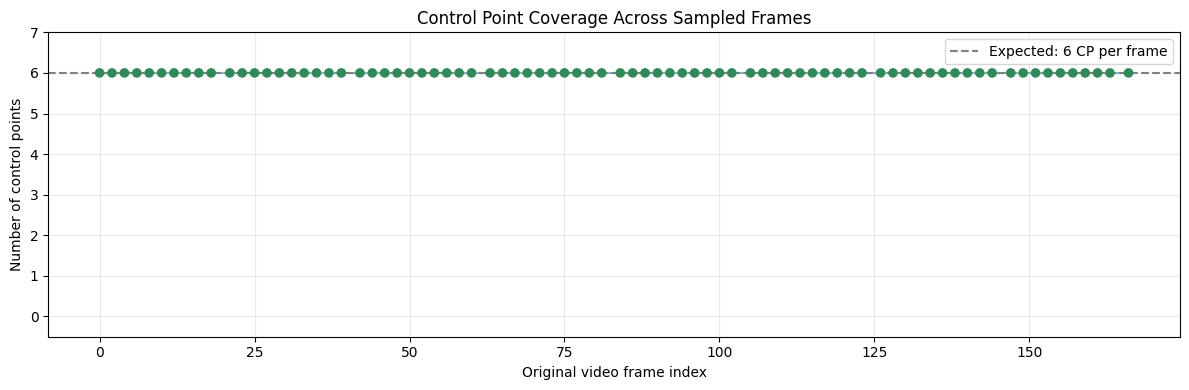

In [46]:
import matplotlib.pyplot as plt

cp_counts = (
    cp_test_df.groupby("frame").size()
    if not cp_test_df.empty
    else pd.Series(dtype=int)
)

frame_check = pd.DataFrame({"frame": test_frame_indices})
frame_check["cp_count"] = (
    frame_check["frame"].map(cp_counts).fillna(0).astype(int)
)

expected = len(CONTROL_POINT_NAMES)
complete = frame_check["cp_count"].eq(expected)
missing = frame_check["cp_count"].eq(0)

print(f"Every sampled frame has CP: {bool((~missing).all())}")
print(f"Every sampled frame has {expected} CP: {bool(complete.all())}")
print(f"Frames without CP: {missing.sum()} / {len(frame_check)}")

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    frame_check["frame"],
    frame_check["cp_count"],
    color="steelblue",
    alpha=0.6,
)
ax.scatter(
    frame_check["frame"],
    frame_check["cp_count"],
    c=np.where(complete, "seagreen", "crimson"),
    s=35,
    zorder=3,
)
ax.axhline(
    expected,
    color="gray",
    linestyle="--",
    label=f"Expected: {expected} CP per frame",
)

ax.set(
    title="Control Point Coverage Across Sampled Frames",
    xlabel="Original video frame index",
    ylabel="Number of control points",
    ylim=(-0.5, max(expected, frame_check["cp_count"].max()) + 1),
)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
save_control_points_plot(fig, "control_point_coverage")
plt.show()

Evaluated frames: 80
Complete frames: 80
Frames with coincident points: 80
Frames with overlapping dots: 80
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_completeness_and_overlap.png
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_completeness_and_overlap.pdf


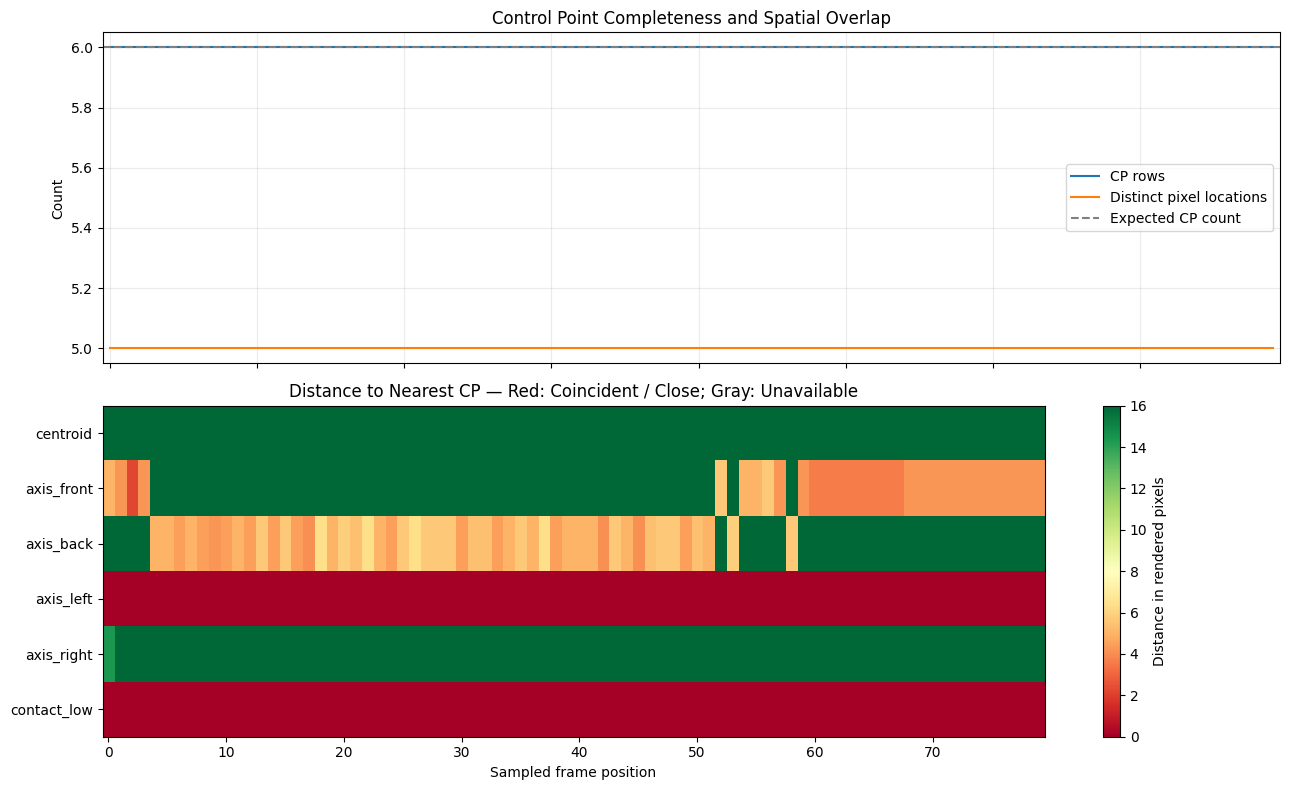

Incomplete frames:


,frame,cp_count,unique_pixel_locations,missing_names,duplicate_names,unexpected_names,invalid_coordinates,complete,overlapping_pairs


Point pairs that overlap most often:


evaluated_frames  coincident_frames  \
point_a    point_b                                            
axis_left  contact_low                80                 80   
axis_back  axis_left                  80                  0   
           contact_low                80                  0   
axis_front axis_left                  80                  0   
           contact_low                80                  0   
axis_back  axis_right                 80                  0   
axis_front axis_back                  80                  0   
           axis_right                 80                  0   
axis_left  axis_right                 80                  0   
axis_right contact_low                80                  0   
centroid   axis_back                  80                  0   
           axis_front                 80                  0   
           axis_left                  80                  0   
           axis_right                 80                  0   
           contact_low                80                  0   

                        overlapping_frames  median_distance_px  
point_a    point_b                                              
axis_left  contact_low                  80            0.000000  
axis_back  axis_left                    50            5.656854  
           contact_low                  50            5.656854  
axis_front axis_left                    30           55.326305  
           contact_low                  30           55.326305  
axis_back  axis_right                    0           54.561891  
axis_front axis_back                     0           60.008333  
           axis_right                    0           35.846897  
axis_left  axis_right                    0           53.037722  
axis_right contact_low                   0           53.037722  
centroid   axis_back                     0           34.460115  
           axis_front                    0           34.000000  
           axis_left                     0           32.326223  
           axis_right                    0           21.400935  
           contact_low                   0           32.326223

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPECTED_CP = list(CONTROL_POINT_NAMES)
DOT_RADIUS = 4
OVERLAP_DISTANCE = 2 * DOT_RADIUS

eval_rows = []
pair_rows = []

for frame_idx in test_frame_indices:
    frame_idx = int(frame_idx)

    rows = (
        cp_test_df.loc[cp_test_df["frame"] == frame_idx].copy()
        if not cp_test_df.empty
        else pd.DataFrame(columns=["point_name", "x", "y"])
    )

    names = rows["point_name"]
    missing_names = sorted(set(EXPECTED_CP) - set(names))
    unexpected_names = sorted(set(names) - set(EXPECTED_CP))
    duplicate_names = sorted(names[names.duplicated()].unique())

    xy = rows[["x", "y"]].to_numpy(dtype=float)
    finite = np.isfinite(xy).all(axis=1)
    valid_rows = rows.loc[finite]
    valid_xy = xy[finite]

    # Coordinates actually used by cv2.circle.
    pixel_xy = np.rint(valid_xy).astype(int)
    unique_locations = len(np.unique(pixel_xy, axis=0))

    distances = []

    for i in range(len(valid_rows)):
        for j in range(i + 1, len(valid_rows)):
            name_a = valid_rows.iloc[i]["point_name"]
            name_b = valid_rows.iloc[j]["point_name"]

            distance = float(np.linalg.norm(pixel_xy[i] - pixel_xy[j]))
            distances.append(distance)

            pair_rows.append({
                "frame": frame_idx,
                "point_a": name_a,
                "point_b": name_b,
                "distance_px": distance,
                "same_pixel": distance == 0,
                "dots_overlap": distance < OVERLAP_DISTANCE,
            })

    eval_rows.append({
        "frame": frame_idx,
        "cp_count": len(rows),
        "unique_pixel_locations": unique_locations,
        "missing_names": ", ".join(missing_names),
        "duplicate_names": ", ".join(duplicate_names),
        "unexpected_names": ", ".join(unexpected_names),
        "invalid_coordinates": int((~finite).sum()),
        "complete": (
            len(rows) == len(EXPECTED_CP)
            and not missing_names
            and not duplicate_names
            and not unexpected_names
            and finite.all()
        ),
        "overlapping_pairs": sum(d < OVERLAP_DISTANCE for d in distances),
    })

cp_eval_df = pd.DataFrame(eval_rows)
cp_pair_eval_df = pd.DataFrame(
    pair_rows,
    columns=[
        "frame", "point_a", "point_b",
        "distance_px", "same_pixel", "dots_overlap",
    ],
)

print(f"Evaluated frames: {len(cp_eval_df)}")
print(f"Complete frames: {cp_eval_df['complete'].sum()}")
print(
    "Frames with coincident points:",
    int((cp_eval_df["unique_pixel_locations"] < cp_eval_df["cp_count"]).sum()),
)
print(
    "Frames with overlapping dots:",
    int((cp_eval_df["overlapping_pairs"] > 0).sum()),
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(
    cp_eval_df["frame"], cp_eval_df["cp_count"],
    label="CP rows", marker=".", color="steelblue",
)
axes[0].plot(
    cp_eval_df["frame"], cp_eval_df["unique_pixel_locations"],
    label="Distinct pixel locations", marker=".", color="darkorange",
)
axes[0].axhline(
    len(EXPECTED_CP), color="gray", linestyle="--",
    label="Expected CP count",
)
axes[0].set_title("Control Point Completeness and Spatial Overlap")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Each row is a named CP; missing/invalid points remain NaN.
distance_by_point = pd.DataFrame(
    np.nan,
    index=EXPECTED_CP,
    columns=[int(f) for f in test_frame_indices],
)

for frame_idx, group in cp_pair_eval_df.groupby("frame"):
    for name in EXPECTED_CP:
        pairs = group[
            (group["point_a"] == name) | (group["point_b"] == name)
        ]
        if not pairs.empty:
            distance_by_point.loc[name, frame_idx] = pairs["distance_px"].min()

cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("lightgray")

heatmap = axes[1].imshow(
    np.ma.masked_invalid(distance_by_point.to_numpy()),
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,
    vmax=OVERLAP_DISTANCE * 2,
    extent=(
        -0.5, len(test_frame_indices) - 0.5,
        len(EXPECTED_CP) - 0.5, -0.5,
    ),
)
# Use sampled-frame positions for both plots.
axes[0].clear()
axes[0].plot(cp_eval_df["cp_count"].to_numpy(), label="CP rows")
axes[0].plot(
    cp_eval_df["unique_pixel_locations"].to_numpy(),
    label="Distinct pixel locations",
)
axes[0].axhline(
    len(EXPECTED_CP), color="gray", linestyle="--",
    label="Expected CP count",
)
axes[0].set_title("Control Point Completeness and Spatial Overlap")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_yticks(range(len(EXPECTED_CP)))
axes[1].set_yticklabels(EXPECTED_CP)
axes[1].set_xlabel("Sampled frame position")
axes[1].set_title(
    "Distance to Nearest CP — Red: Coincident / Close; Gray: Unavailable"
)
fig.colorbar(heatmap, ax=axes[1], label="Distance in rendered pixels")

plt.tight_layout()
save_control_points_plot(fig, "control_point_completeness_and_overlap")
plt.show()

print("Incomplete frames:")
display(cp_eval_df.loc[~cp_eval_df["complete"]])

print("Point pairs that overlap most often:")
pair_summary = (
    cp_pair_eval_df.groupby(["point_a", "point_b"])
    .agg(
        evaluated_frames=("frame", "nunique"),
        coincident_frames=("same_pixel", "sum"),
        overlapping_frames=("dots_overlap", "sum"),
        median_distance_px=("distance_px", "median"),
    )
    .sort_values("overlapping_frames", ascending=False)
)
display(pair_summary)

### All Videos Data Representation

**Control Point Dataset Construction**

We extract control points from evenly sampled frames across each selected LunarLander expert video and combine the observations into a single dataset. Each row records one control point, its spatial coordinates, and the episode and frame identifiers needed to reconstruct its temporal sequence.

**Even Sampling and Sequence Length**

Even sampling distributes observations across the full episode while controlling sequence length. This supports the subsequent construction of fixed-size matrices, in which each episode follows the same temporal layout. We use a common target number of sampled frames; shorter videos and missing detections still require padding and availability masks to obtain equal-sized inputs.

**Temporal Spacing and Motion Visibility**

As an initial design choice, we use the temporal spacing induced by this sampling procedure rather than tuning a separate stride. Consecutive video frames may exhibit displacements that are small relative to pixel resolution and fluctuations in the extracted control points, making action-related motion difficult to distinguish. Sampling at wider intervals can make these changes more apparent, although overly large intervals may obscure brief movements. Because episode lengths vary, the effective spacing can differ across videos; we therefore retain the original frame indices for subsequent temporal calculations.

In [37]:
# Control Points - Loop over selected Lunar Lander expert videos

control_point_rows = []

for episode_id, video_path in enumerate(tqdm(lunar_video_paths, desc="control points")):
    frames, frame_indices = read_video_even(
        video_path,
        max_frames=MAX_FRAMES_PER_EPISODE,
        return_indices=True,
    )

    for local_frame_idx, frame in enumerate(frames):
        source_frame_idx = int(frame_indices[local_frame_idx])
        records = lunar_lander_agent_records(frame)

        for track_id, record in enumerate(records):
            cp_rows = control_points_from_record(record)

            for row in cp_rows:
                row.update(
                    {
                        "episode_id": episode_id,
                        "video_path": str(video_path),
                        "frame": source_frame_idx,
                        "local_frame": local_frame_idx,
                        "track_id": track_id,
                    }
                )
                control_point_rows.append(row)

lunar_cp_df = pd.DataFrame(control_point_rows)

lunar_cp_df["point_name"] = pd.Categorical(
    lunar_cp_df["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

lunar_cp_df = lunar_cp_df.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("lunar_cp_df:", lunar_cp_df.shape)
print(lunar_cp_df.head())

control points: 100%|██████████| 500/500 [10:58<00:00,  1.32s/it]


lunar_cp_df: (238158, 15)
   point_name           x         y  box_x1  box_y1  box_x2  box_y2  area  \
0    centroid  299.810403   5.20302     268       0     332      15   596   
1  axis_front  268.000000  11.00000     268       0     332      15   596   
2   axis_back  331.000000  11.00000     268       0     332      15   596   
3   axis_left  271.000000  14.00000     268       0     332      15   596   
4  axis_right  273.000000   0.00000     268       0     332      15   596   

           class_name                       source  episode_id  \
0  lunar_lander_agent  env_specific_color_geometry           0   
1  lunar_lander_agent  env_specific_color_geometry           0   
2  lunar_lander_agent  env_specific_color_geometry           0   
3  lunar_lander_agent  env_specific_color_geometry           0   
4  lunar_lander_agent  env_specific_color_geometry           0   

                                          video_path  frame  local_frame  \
0  /Users/adriankazi/Desktop/Desktop -

##### Evaluation

saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_summary_episode_241.png
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/control_point_summary_episode_241.pdf


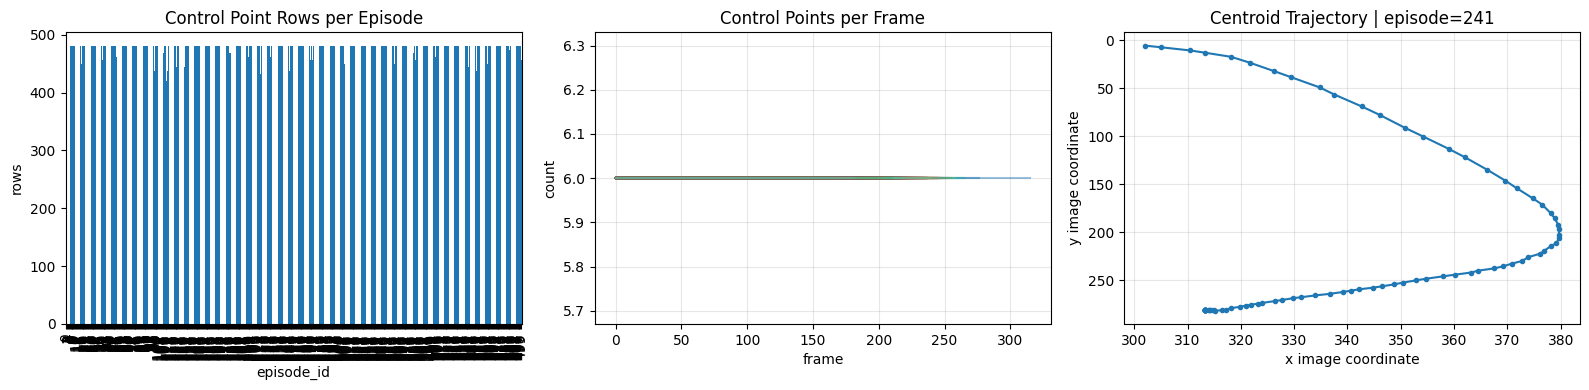

sample_episode_id: 241
control point rows per episode:
episode_id
0      480
1      480
2      480
3      480
4      480
5      480
6      480
7      480
8      480
9      480
10     480
11     480
12     462
13     480
14     480
15     456
16     480
17     450
18     480
19     480
20     480
21     480
22     480
23     480
24     480
25     480
26     480
27     480
28     480
29     480
30     480
31     480
32     480
33     462
34     480
35     480
36     480
37     480
38     480
39     480
40     456
41     480
42     480
43     480
44     480
45     480
46     480
47     480
48     480
49     474
50     480
51     480
52     480
53     480
54     480
55     462
56     480
57     480
58     426
59     462
60     480
61     450
62     480
63     480
64     480
65     480
66     480
67     480
68     456
69     480
70     480
71     480
72     480
73     480
74     480
75     480
76     480
77     480
78     480
79     480
80     480
81     480
82     480
83     480
84     480

In [48]:
# Control Points - Visual Review

cp_counts_per_episode = lunar_cp_df.groupby("episode_id").size()
cp_points_per_frame = (
    lunar_cp_df
    .groupby(["episode_id", "frame"])
    .size()
    .reset_index(name="n_control_points")
)

sample_episode_id = int(np.random.choice(sorted(lunar_cp_df["episode_id"].unique())))
sample_cp = lunar_cp_df[
    (lunar_cp_df["episode_id"] == sample_episode_id)
    & (lunar_cp_df["point_name"] == "centroid")
].sort_values("frame")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

cp_counts_per_episode.plot(kind="bar", ax=ax[0])
ax[0].set_title("Control Point Rows per Episode")
ax[0].set_xlabel("episode_id")
ax[0].set_ylabel("rows")

for episode_id, group in cp_points_per_frame.groupby("episode_id"):
    ax[1].plot(group["frame"], group["n_control_points"], alpha=0.45)
ax[1].set_title("Control Points per Frame")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("count")
ax[1].grid(alpha=0.3)

ax[2].plot(sample_cp["x"], sample_cp["y"], marker="o", markersize=3)
ax[2].invert_yaxis()
ax[2].set_title(f"Centroid Trajectory | episode={sample_episode_id}")
ax[2].set_xlabel("x image coordinate")
ax[2].set_ylabel("y image coordinate")
ax[2].grid(alpha=0.3)

plt.tight_layout()
save_control_points_plot(fig, f"control_point_summary_episode_{sample_episode_id}")
plt.show()

print("sample_episode_id:", sample_episode_id)
print("control point rows per episode:")
print(cp_counts_per_episode.to_string())


saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/frame_coverage_all_episodes.png
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/control_points/frame_coverage_all_episodes.pdf


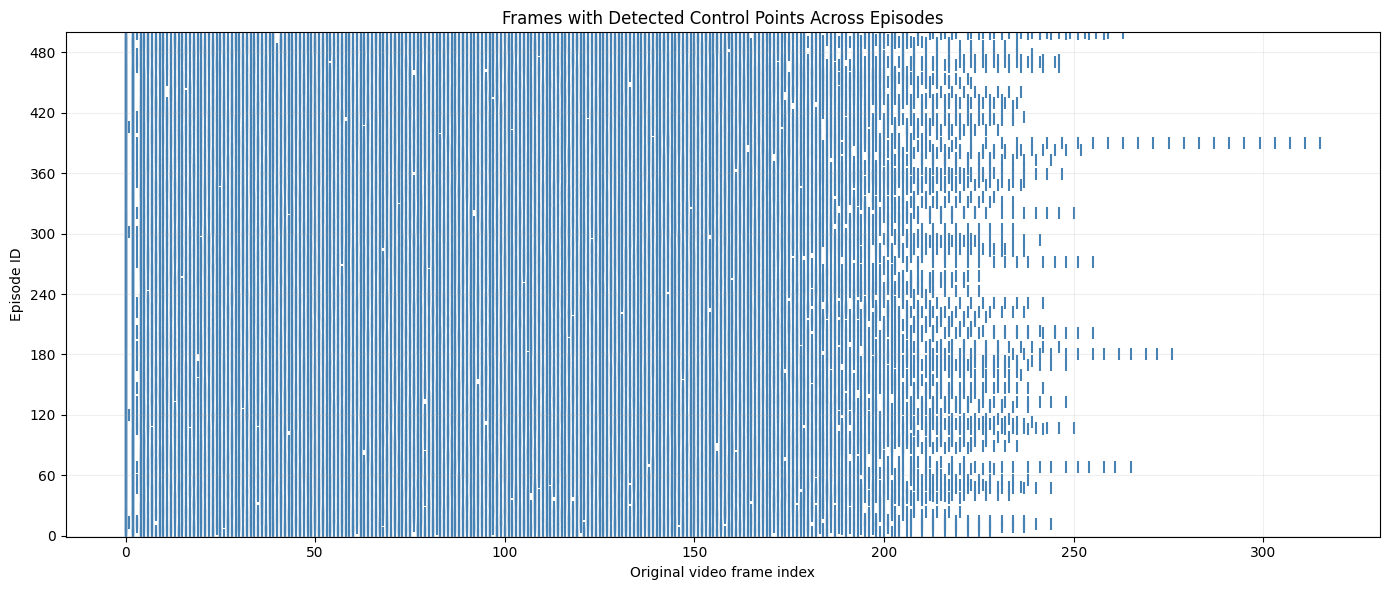

,frames_with_cp,first_frame_with_cp,last_frame_with_cp
episode_id,,,
0,80,0,169
1,80,0,206
2,80,0,185
3,80,0,165
4,80,0,228
...,...,...,...
495,80,0,203
496,80,0,181
497,80,0,164


In [49]:
# Frame coverage across all episodes — frames with detected CP.

import matplotlib.pyplot as plt

episode_ids = range(len(lunar_video_paths))

fig, ax = plt.subplots(figsize=(14, 6))

for episode_id in episode_ids:
    episode_frames = (
        lunar_cp_df.loc[lunar_cp_df["episode_id"] == episode_id, "frame"]
        .drop_duplicates()
        .sort_values()
        .to_numpy()
    )

    ax.scatter(
        episode_frames,
        [episode_id] * len(episode_frames),
        marker="|",
        s=70,
        color="steelblue",
    )

ax.set(
    title="Frames with Detected Control Points Across Episodes",
    xlabel="Original video frame index",
    ylabel="Episode ID",
    ylim=(-1, len(lunar_video_paths)),
)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(alpha=0.2)
plt.tight_layout()
save_control_points_plot(fig, "frame_coverage_all_episodes")
plt.show()

summary = (
    lunar_cp_df.groupby("episode_id")
    .agg(
        frames_with_cp=("frame", "nunique"),
        first_frame_with_cp=("frame", "min"),
        last_frame_with_cp=("frame", "max"),
    )
    .reindex(episode_ids)
)

summary["frames_with_cp"] = summary["frames_with_cp"].fillna(0).astype(int)
display(summary)

### Save

In [50]:
# Control Points - Save

CONTROL_POINTS_DIR.mkdir(parents=True, exist_ok=True)

control_points_output_path = (
    CONTROL_POINTS_DIR / "lunar_lander_control_points.csv"
)

lunar_cp_df.to_csv(control_points_output_path, index=False)

print("saved:", control_points_output_path)
print("shape:", lunar_cp_df.shape)
print("episodes with CP:", lunar_cp_df["episode_id"].nunique())

saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/control_points/lunar_lander_control_points.csv
shape: (238158, 15)
episodes with CP: 500


### Load

In [51]:
# Control Points - Load saved dataset

control_points_output_path = (
    CONTROL_POINTS_DIR / "lunar_lander_control_points.csv"
)

lunar_cp_df = pd.read_csv(control_points_output_path)

lunar_cp_df["point_name"] = pd.Categorical(
    lunar_cp_df["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

lunar_cp_df = lunar_cp_df.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("loaded:", control_points_output_path)
print("shape:", lunar_cp_df.shape)
print("episodes with CP:", lunar_cp_df["episode_id"].nunique())

display(lunar_cp_df.head())

loaded: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/control_points/lunar_lander_control_points.csv
shape: (238158, 15)
episodes with CP: 500


,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,299.810403,5.20302,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
1,axis_front,268.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
2,axis_back,331.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
3,axis_left,271.000000,14.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
4,axis_right,273.000000,0.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0


## Background Points

**Background Points as a Spatial Reference**

Background points provide a spatial reference for interpreting the motion of an agent. Observed image motion depends on both the agent’s movement and the camera’s movement. For example, when a camera follows a moving car at a similar speed, the car may remain almost stationary in the image despite moving through the environment. A stationary roadside camera would observe a different trajectory for the same action. Background observations can help distinguish these situations by providing context for the agent’s motion relative to its surroundings.

**Static Background Grid in LunarLander**

In the current LunarLander experiments, we use a simple two-dimensional grid because the environment is rendered from a fixed camera and does not involve motion into or out of the image plane. Grid points retain fixed image coordinates and stable identifiers throughout each episode. Points covered by the detected lander mask, expanded by a small margin, are temporarily excluded and become available again when uncovered.

This grid provides a consistent image-space reference for the model. Its coordinates are fixed by construction, so their zero displacement is not an estimate of background motion. The current setup therefore supports experiments with a stationary viewpoint but does not evaluate camera-motion compensation.

**Extension to Moving Cameras and Scene Depth**

For real-world videos with moving cameras and substantial depth variation, a fixed image grid would not provide persistent correspondences to the environment. Such settings call for methods designed for visual point tracking, camera-motion estimation, or depth and three-dimensional scene reconstruction. These methods could provide background observations against which the model interprets agent motion, including cases where an agent remains approximately stationary in the camera view.

Computational cost is a major practical consideration when applying these methods across large video datasets, particularly for dense tracking and three-dimensional reconstruction. Such processing is feasible, but runtime and memory requirements must be balanced against the quality of the resulting representation. Correspondence errors, occlusions, and depth ambiguity also require consideration. We therefore adopt a static grid for the present experiments and leave richer background representations to future evaluation.

### Model

In [59]:
# Background Segmentation - Static Base Grid

BACKGROUND_GRID_STEP = 40
BACKGROUND_GRID_MARGIN = 20
BACKGROUND_Y_START_RATIO = 0.0
BACKGROUND_AGENT_DILATE_PX = 7
BACKGROUND_MAX_POINTS = 160


class BackgroundBaseGridModel:
    def __init__(
        self,
        y_start_ratio=BACKGROUND_Y_START_RATIO,
        step=BACKGROUND_GRID_STEP,
        margin=BACKGROUND_GRID_MARGIN,
        agent_dilate_px=BACKGROUND_AGENT_DILATE_PX,
        max_points=BACKGROUND_MAX_POINTS,
        scene_type="lunar_lander",
    ):
        self.y_start_ratio = float(y_start_ratio)
        self.step = int(step)
        self.margin = int(margin)
        self.agent_dilate_px = int(agent_dilate_px)
        self.max_points = None if max_points is None else int(max_points)
        self.scene_type = scene_type

        if self.step <= 0:
            raise ValueError("step must be positive")
        if self.margin < 0 or self.agent_dilate_px < 0:
            raise ValueError("margin and agent_dilate_px must be nonnegative")
        if not 0 <= self.y_start_ratio <= 1:
            raise ValueError("y_start_ratio must be between 0 and 1")
        if self.max_points is not None and self.max_points <= 0:
            raise ValueError("max_points must be positive or None")

    def agent_records(self, frame):
        return active_agent_records(frame, scene_type=self.scene_type)

    def agent_inverse_mask(self, frame, records=None):
        if records is None:
            records = self.agent_records(frame)

        active_mask = np.zeros(frame.shape[:2], dtype=bool)

        for record in records:
            active_mask |= record["mask"]

        if self.agent_dilate_px > 0 and active_mask.any():
            size = 2 * self.agent_dilate_px + 1
            active_mask = cv2.dilate(
                active_mask.astype(np.uint8),
                np.ones((size, size), dtype=np.uint8),
                iterations=1,
            ).astype(bool)

        return ~active_mask, active_mask, records

    def lower_base_mask(self, frame, background_mask):
        mask = np.asarray(background_mask, dtype=bool).copy()
        first_y = int(frame.shape[0] * self.y_start_ratio)
        mask[:first_y] = False
        return mask

    def make_base_grid_points(self, base_mask):
        h, w = base_mask.shape

        points = [
            (float(x), float(y))
            for y in range(self.margin, h - self.margin, self.step)
            for x in range(self.margin, w - self.margin, self.step)
            if base_mask[y, x]
        ]

        points = np.asarray(points, dtype=np.float32).reshape(-1, 2)

        if self.max_points is not None and len(points) > self.max_points:
            keep = np.linspace(
                0, len(points) - 1, self.max_points, dtype=int
            )
            points = points[keep]

        return points

    def fit_base_grid(self, frame):
        # Grid membership does not depend on the first agent position.
        region_mask = self.lower_base_mask(
            frame,
            np.ones(frame.shape[:2], dtype=bool),
        )
        points = self.make_base_grid_points(region_mask)

        background_mask, active_mask, records = self.agent_inverse_mask(frame)
        base_mask = self.lower_base_mask(frame, background_mask)

        return {
            "region_mask": region_mask,
            "base_mask": base_mask,
            "background_mask": background_mask,
            "active_mask": active_mask,
            "records": records,
            "points": points,
            "point_ids": np.arange(len(points), dtype=int),
        }

    def valid_points_for_frame(self, frame, points):
        background_mask, active_mask, records = self.agent_inverse_mask(frame)
        base_mask = self.lower_base_mask(frame, background_mask)

        points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
        valid = np.zeros(len(points), dtype=bool)

        if len(points):
            h, w = base_mask.shape
            finite = np.isfinite(points).all(axis=1)
            ids = np.flatnonzero(finite)
            pixels = np.rint(points[finite]).astype(int)

            inside = (
                (pixels[:, 0] >= 0)
                & (pixels[:, 0] < w)
                & (pixels[:, 1] >= 0)
                & (pixels[:, 1] < h)
            )

            ids = ids[inside]
            pixels = pixels[inside]
            valid[ids] = base_mask[pixels[:, 1], pixels[:, 0]]

        return valid, background_mask, active_mask, records

    def build_rows(self, frames, source_indices, episode_id=None, video_path=None):
        if len(frames) == 0:
            raise ValueError("No frames provided")

        source_indices = np.asarray(source_indices, dtype=int)

        if len(frames) != len(source_indices):
            raise ValueError("frames and source_indices must have equal lengths")
        if np.any(np.diff(source_indices) <= 0):
            raise ValueError("source_indices must be strictly increasing")
        if any(frame.shape[:2] != frames[0].shape[:2] for frame in frames):
            raise ValueError("All frames must have the same spatial dimensions")

        base = self.fit_base_grid(frames[0])
        points = base["points"]
        point_ids = base["point_ids"]

        seen = set()
        rows = []

        for frame, source_frame in zip(frames, source_indices):
            valid, _, _, _ = self.valid_points_for_frame(frame, points)

            for point_id, (x, y), is_valid in zip(point_ids, points, valid):
                if not is_valid:
                    continue

                point_id = int(point_id)
                prev_valid = point_id in seen

                row = {
                    "frame": int(source_frame),
                    "background_point_id": point_id,
                    "x": float(x),
                    "y": float(y),
                    # Fixed image coordinates, not estimated optical flow.
                    "dx": 0.0 if prev_valid else np.nan,
                    "dy": 0.0 if prev_valid else np.nan,
                    "speed": 0.0 if prev_valid else np.nan,
                    "valid": True,
                    # An earlier valid observation exists, possibly across a gap.
                    "prev_valid": prev_valid,
                }

                if episode_id is not None:
                    row["episode_id"] = int(episode_id)
                if video_path is not None:
                    row["video_path"] = str(video_path)

                rows.append(row)
                seen.add(point_id)

        return rows, base

    def render(
        self,
        frame,
        base_mask,
        active_mask,
        points,
        title="Background static grid",
    ):
        image = frame.copy()

        image[base_mask] = (
            image[base_mask] * 0.55
            + np.array([40, 180, 90]) * 0.45
        ).astype(np.uint8)

        image[active_mask] = (
            image[active_mask] * 0.45
            + np.array([230, 50, 40]) * 0.55
        ).astype(np.uint8)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(image)

        if len(points):
            ax.scatter(
                points[:, 0],
                points[:, 1],
                s=12,
                c="yellow",
                edgecolors="black",
                linewidths=0.3,
            )

        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        return fig


background_base_grid_model = BackgroundBaseGridModel()


def get_background_grid_model(scene_type=None, step=None):
    base = background_base_grid_model
    scene_type = base.scene_type if scene_type is None else scene_type
    step = base.step if step is None else int(step)

    if scene_type == base.scene_type and step == base.step:
        return base

    return BackgroundBaseGridModel(
        y_start_ratio=base.y_start_ratio,
        step=step,
        margin=base.margin,
        agent_dilate_px=base.agent_dilate_px,
        max_points=base.max_points,
        scene_type=scene_type,
    )


def surface_grid_background_mask(frame, scene_type="lunar_lander"):
    model = get_background_grid_model(scene_type=scene_type)
    background_mask, active_mask, records = model.agent_inverse_mask(frame)
    base_mask = model.lower_base_mask(frame, background_mask)
    return base_mask, active_mask, records


def track_surface_grid_points(
    frames,
    frame_indices=None,
    step=None,
    scene_type="lunar_lander",
    source_indices=None,
    keep_source_frames=None,
):
    # Compatibility name: this produces a static grid, not optical-flow tracks.
    if source_indices is None:
        source_indices = frame_indices
    if source_indices is None:
        source_indices = np.arange(len(frames), dtype=int)

    source_indices = np.asarray(source_indices, dtype=int)

    if len(frames) != len(source_indices):
        raise ValueError("frames and source_indices must have equal lengths")

    if keep_source_frames is not None:
        keep = np.isin(source_indices, list(keep_source_frames))
        frames = [frame for frame, selected in zip(frames, keep) if selected]
        source_indices = source_indices[keep]

    if len(frames) == 0:
        return []

    model = get_background_grid_model(scene_type=scene_type, step=step)
    rows, _ = model.build_rows(frames, source_indices)
    return rows


def tracks_to_background_dataframe(tracks, episode_id, video_path):
    columns = [
        "episode_id",
        "video_path",
        "frame",
        "background_point_id",
        "x",
        "y",
        "dx",
        "dy",
        "speed",
        "valid",
        "prev_valid",
    ]

    df = pd.DataFrame(tracks)

    if df.empty:
        return pd.DataFrame(columns=columns)

    if "episode_id" not in df.columns:
        df["episode_id"] = int(episode_id)
    if "video_path" not in df.columns:
        df["video_path"] = str(video_path)

    return (
        df[columns]
        .sort_values(["episode_id", "frame", "background_point_id"])
        .reset_index(drop=True)
    )


def build_background_points_for_video(
    video_path,
    episode_id,
    max_frames=MAX_FRAMES_PER_EPISODE,
):
    frames, frame_indices = read_video_even(
        video_path,
        max_frames=max_frames,
        return_indices=True,
    )

    rows, _ = background_base_grid_model.build_rows(
        frames,
        frame_indices,
        episode_id=episode_id,
        video_path=video_path,
    )

    episode_bckg_df = tracks_to_background_dataframe(
        rows, episode_id, video_path
    )

    return (
        episode_bckg_df,
        int(video_frame_count(video_path)),
        int(len(frame_indices)),
    )


def show_surface_grid_tracking_experiment(
    frames,
    frame_idx,
    title,
    video_name="surface_grid_tracking.mp4",
    scene_type="lunar_lander",
    source_indices=None,
):
    if source_indices is None:
        source_indices = np.arange(len(frames), dtype=int)

    source_indices = np.asarray(source_indices, dtype=int)
    model = get_background_grid_model(scene_type=scene_type)

    rows, base = model.build_rows(frames, source_indices)
    df = pd.DataFrame(
        rows,
        columns=[
            "frame", "background_point_id", "x", "y",
            "dx", "dy", "speed", "valid", "prev_valid",
        ],
    )

    # frame_idx denotes an original/source frame index.
    matches = np.flatnonzero(source_indices == int(frame_idx))
    if len(matches) == 0:
        raise ValueError(
            f"Frame {frame_idx} is not present in source_indices"
        )

    local_idx = int(matches[0])
    frame_source = int(source_indices[local_idx])
    review_df = df.loc[df["frame"] == frame_source]

    # Recompute masks for the actual preview frame.
    valid, background_mask, active_mask, _ = model.valid_points_for_frame(
        frames[local_idx], base["points"]
    )
    base_mask = model.lower_base_mask(
        frames[local_idx], background_mask
    )

    preview_fig = model.render(
        frames[local_idx],
        base_mask,
        active_mask,
        base["points"][valid],
        title=title,
    )

    annotated_frames = []

    for image, source_frame in zip(frames, source_indices):
        image = image.copy()
        frame_df = df.loc[df["frame"] == int(source_frame)]

        for row in frame_df.itertuples(index=False):
            cv2.circle(
                image,
                (int(round(row.x)), int(round(row.y))),
                2,
                (235, 70, 50),
                -1,
            )

        cv2.putText(
            image,
            f"frame {int(source_frame)} | visible grid points {len(frame_df)}",
            (12, 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        annotated_frames.append(image)

    video_path = show_video(
        np.stack(annotated_frames),
        video_name,
        fps=30,
        embed=True,
    )

    summary = pd.DataFrame([{
        "frame": frame_source,
        "base_region": (
            "full image inverse-agent mask"
            if model.y_start_ratio == 0
            else f"inverse-agent mask below y/H={model.y_start_ratio:g}"
        ),
        "base_grid_points": len(base["points"]),
        "visible_points": len(review_df),
        "y_start_ratio": model.y_start_ratio,
        "step": model.step,
        "max_points": model.max_points,
    }])

    display(summary)
    display(review_df.head(30))

    return rows, frames, {
        "frame_df": review_df,
        "all_points_df": df,
        "summary": summary,
        "figure": preview_fig,
        "video_path": video_path,
    }

### Single Video Data Representation

test video: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/lunarlander_expert/videos/expert_pretrain/lunar_lander_expert-episode-296.mp4
original frames: 203
sampled frames: (80, 400, 600, 3)
first sampled frame: 0
last sampled frame: 202
frame_idx: 25


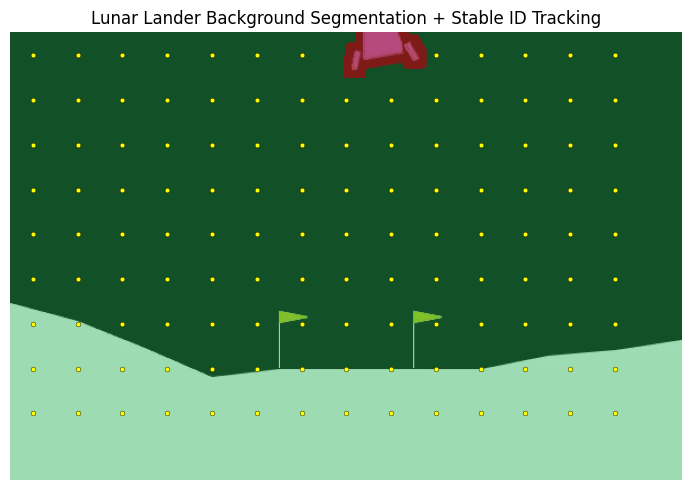

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


,frame,base_region,base_grid_points,visible_points,y_start_ratio,step,max_points
0,25,full image inverse-agent mask,126,124,0.0,40,160


,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
1255,25,0,20.0,20.0,0.0,0.0,0.0,True,True
1256,25,1,60.0,20.0,0.0,0.0,0.0,True,True
1257,25,2,100.0,20.0,0.0,0.0,0.0,True,True
1258,25,3,140.0,20.0,0.0,0.0,0.0,True,True
1259,25,4,180.0,20.0,0.0,0.0,0.0,True,True
1260,25,5,220.0,20.0,0.0,0.0,0.0,True,True
1261,25,6,260.0,20.0,0.0,0.0,0.0,True,True
1262,25,9,380.0,20.0,0.0,0.0,0.0,True,True
1263,25,10,420.0,20.0,0.0,0.0,0.0,True,True
1264,25,11,460.0,20.0,0.0,0.0,0.0,True,True


In [63]:
# Background Segmentation - Test on One Video

test_video_path = np.random.choice(lunar_video_paths)
frames, frame_indices = read_video_even(
    test_video_path,
    max_frames=MAX_FRAMES_PER_EPISODE,
    return_indices=True,
)
frame_idx = int(frame_indices[min(10, len(frame_indices) - 1)])

print("test video:", test_video_path)
print("original frames:", video_frame_count(test_video_path))
print("sampled frames:", frames.shape)
print("first sampled frame:", int(frame_indices[0]))
print("last sampled frame:", int(frame_indices[-1]))
print("frame_idx:", frame_idx)

bg_surface_grid_1_lunar_tracks, bg_surface_grid_1_lunar_frames, bg_surface_grid_1_lunar_data = show_surface_grid_tracking_experiment(
    frames,
    frame_idx,
    "Lunar Lander Background Segmentation + Stable ID Tracking",
    video_name="surface_grid_1_lunar_pretrain_test.mp4",
    scene_type="lunar_lander",
    source_indices=frame_indices,
)

#### Evaluation

Grid points: 126
Minimum available per frame: 123
Maximum available per frame: 126
Frames without points: 0
IDs with changing coordinates: 0


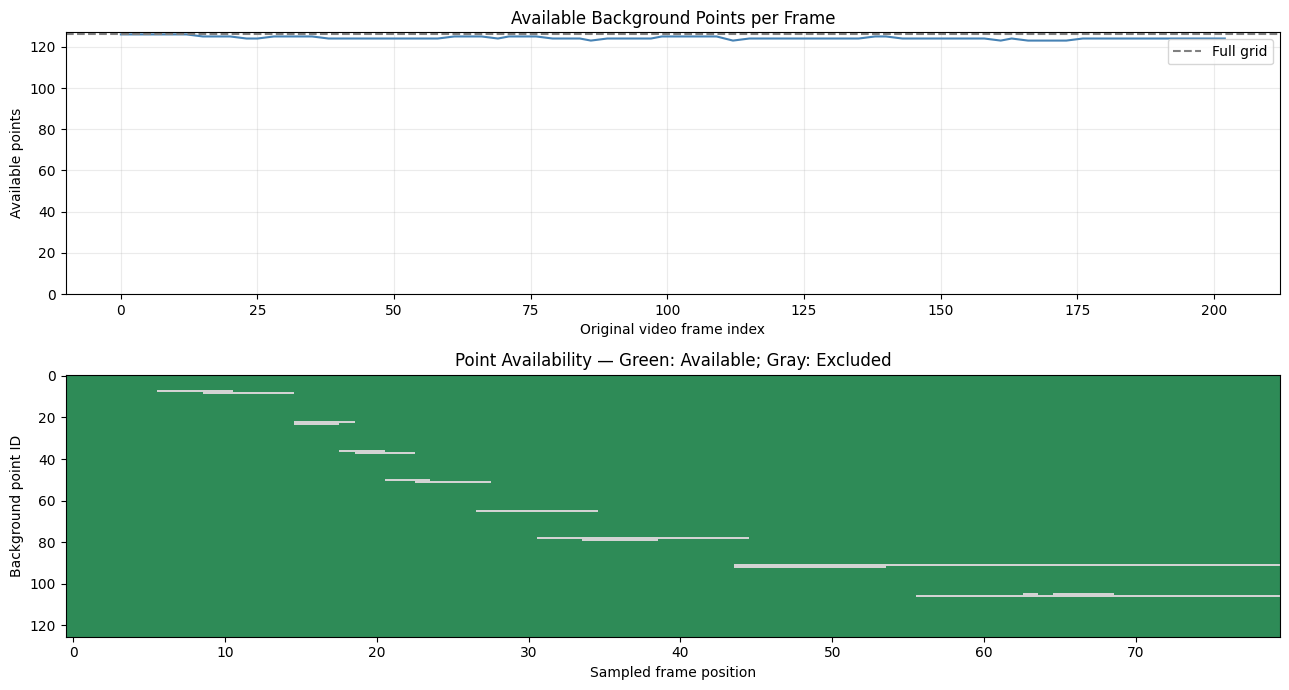

,availability_ratio
background_point_id,
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
121,1.0
122,1.0
123,1.0


In [65]:
# Background Points - Evaluation

bg_df = bg_surface_grid_1_lunar_data["all_points_df"]
base = background_base_grid_model.fit_base_grid(frames[0])
point_ids = base["point_ids"]

availability = pd.DataFrame(
    False, index=point_ids, columns=frame_indices
)

for row in bg_df.itertuples(index=False):
    if row.valid:
        availability.loc[row.background_point_id, row.frame] = True

counts = availability.sum(axis=0)
coverage = availability.mean(axis=1)

coordinate_counts = (
    bg_df.groupby("background_point_id")[["x", "y"]].nunique()
)
moving_ids = coordinate_counts.index[
    coordinate_counts.gt(1).any(axis=1)
]

print("Grid points:", len(point_ids))
print("Minimum available per frame:", int(counts.min()))
print("Maximum available per frame:", int(counts.max()))
print("Frames without points:", int(counts.eq(0).sum()))
print("IDs with changing coordinates:", len(moving_ids))

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(frame_indices, counts.to_numpy(), color="steelblue")
axes[0].axhline(
    len(point_ids), color="gray", linestyle="--", label="Full grid"
)
axes[0].set(
    title="Available Background Points per Frame",
    xlabel="Original video frame index",
    ylabel="Available points",
    ylim=(0, max(1, len(point_ids)) + 1),
)
axes[0].legend()
axes[0].grid(alpha=0.25)

if len(point_ids):
    from matplotlib.colors import ListedColormap

    axes[1].imshow(
        availability.to_numpy(dtype=int),
        aspect="auto",
        interpolation="nearest",
        cmap=ListedColormap(["lightgray", "seagreen"]),
        vmin=0,
        vmax=1,
    )
else:
    axes[1].text(
        0.5, 0.5, "No grid points",
        ha="center", va="center", transform=axes[1].transAxes,
    )

axes[1].set(
    title="Point Availability — Green: Available; Gray: Excluded",
    xlabel="Sampled frame position",
    ylabel="Background point ID",
)

plt.tight_layout()

background_plots_dir = PLOTS_DIR / "background_points"
background_plots_dir.mkdir(parents=True, exist_ok=True)

for extension in ("png", "pdf"):
    fig.savefig(
        background_plots_dir / f"background_point_eval.{extension}",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()

display(
    coverage.rename("availability_ratio")
    .rename_axis("background_point_id")
    .to_frame()
)

### All Videos Data Representation (Save Embedded)

In [66]:
# Background Points - Loop + Save Per Episode

BACKGROUND_POINTS_DIR.mkdir(parents=True, exist_ok=True)

background_output_paths = []
episode_summaries = []

for episode_id, video_path in enumerate(
    tqdm(lunar_video_paths, desc="background points")
):
    episode_bckg_df, n_full_frames, n_sampled_frames = (
        build_background_points_for_video(
            video_path,
            episode_id=episode_id,
            max_frames=MAX_FRAMES_PER_EPISODE,
        )
    )

    episode_output_path = (
        BACKGROUND_POINTS_DIR
        / f"lunar_lander_background_points_episode_{episode_id:04d}.csv"
    )

    episode_bckg_df.to_csv(episode_output_path, index=False)
    background_output_paths.append(episode_output_path)

    episode_summary = {
        "episode_id": int(episode_id),
        "video_path": str(video_path),
        "full_frames": int(n_full_frames),
        "sampled_frames": int(n_sampled_frames),
        "saved_rows": int(len(episode_bckg_df)),
        "background_ids": int(
            episode_bckg_df["background_point_id"].nunique()
        ),
        "points_per_frame_mean": (
            len(episode_bckg_df) / n_sampled_frames
            if n_sampled_frames else 0.0
        ),
    }
    episode_summaries.append(episode_summary)

    tqdm.write(
        f"episode {episode_id + 1}/{len(lunar_video_paths)} | "
        f"full frames {n_full_frames} | "
        f"sampled {n_sampled_frames} | "
        f"rows {len(episode_bckg_df)} | "
        f"ids {episode_summary['background_ids']} | "
        f"saved {episode_output_path.name}"
    )

if not background_output_paths:
    raise ValueError("No videos available for background point extraction.")

lunar_bckg_df = pd.concat(
    [pd.read_csv(path) for path in background_output_paths],
    ignore_index=True,
).sort_values(
    ["episode_id", "frame", "background_point_id"]
).reset_index(drop=True)

# Compatibility aliases for downstream cells.
lunar_bckg_df_reduced = lunar_bckg_df.copy()
lunar_bckg_df_selected = lunar_bckg_df_reduced.copy()

background_episode_summary_df = pd.DataFrame(episode_summaries)
background_episode_summary_df.to_csv(
    BACKGROUND_POINTS_DIR / "background_episode_summary.csv",
    index=False,
)

print("saved episode files:", len(background_output_paths))
print("directory:", BACKGROUND_POINTS_DIR)
print("background shape:", lunar_bckg_df.shape)
print("episodes with points:", lunar_bckg_df["episode_id"].nunique())

display(background_episode_summary_df.head(20))
display(lunar_bckg_df.head(20))

background points:   0%|          | 1/500 [00:01<13:45,  1.65s/it]

episode 1/500 | full frames 170 | sampled 80 | rows 9952 | ids 126 | saved lunar_lander_background_points_episode_0000.csv


background points:   0%|          | 2/500 [00:03<13:35,  1.64s/it]

episode 2/500 | full frames 207 | sampled 80 | rows 9940 | ids 126 | saved lunar_lander_background_points_episode_0001.csv


background points:   1%|          | 3/500 [00:04<13:21,  1.61s/it]

...

episode 499/500 | full frames 259 | sampled 80 | rows 9932 | ids 126 | saved lunar_lander_background_points_episode_0498.csv


background points: 100%|██████████| 500/500 [11:57<00:00,  1.44s/it]


episode 500/500 | full frames 264 | sampled 80 | rows 9953 | ids 126 | saved lunar_lander_background_points_episode_0499.csv
saved episode files: 500
directory: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/background_points
background shape: (4969201, 11)
episodes with points: 500


,episode_id,video_path,full_frames,sampled_frames,saved_rows,background_ids,points_per_frame_mean
0,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,170,80,9952,126,124.4000
1,1,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,207,80,9940,126,124.2500
2,2,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,186,80,9941,126,124.2625
3,3,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,166,80,9937,126,124.2125
4,4,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,229,80,9947,126,124.3375
5,5,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,167,80,9925,126,124.0625
6,6,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,186,80,9933,126,124.1625
7,7,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,198,80,9939,126,124.2375
8,8,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,205,80,9900,126,123.7500
9,9,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,238,80,9913,126,123.9125


,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,4,180.0,20.0,NaN,NaN,NaN,True,False
5,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,5,220.0,20.0,NaN,NaN,NaN,True,False
6,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,6,260.0,20.0,NaN,NaN,NaN,True,False
7,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,7,300.0,20.0,NaN,NaN,NaN,True,False
8,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,8,340.0,20.0,NaN,NaN,NaN,True,False
9,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,9,380.0,20.0,NaN,NaN,NaN,True,False


#### Evaluation

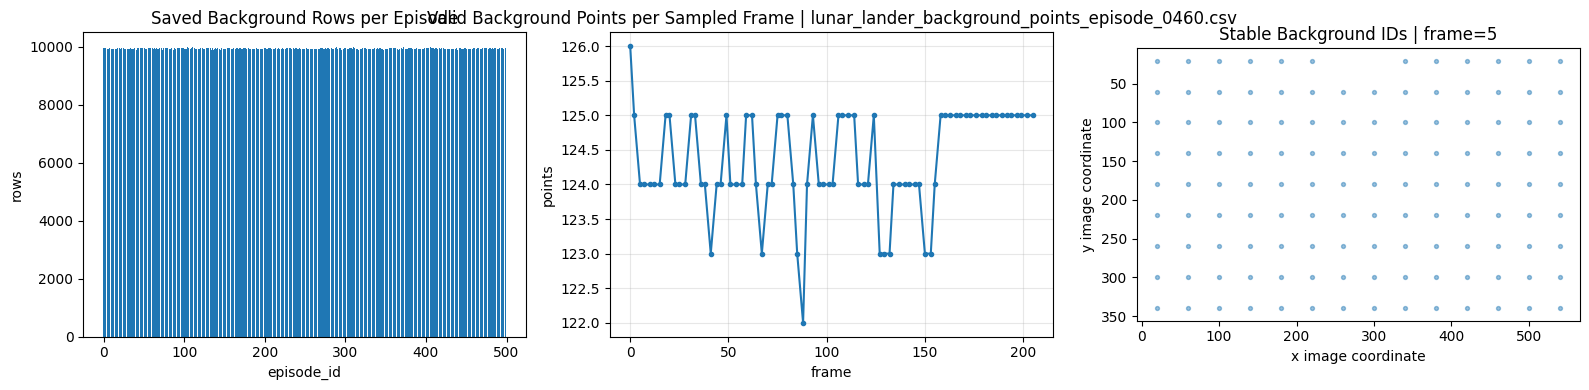

       episode_id         rows  frames  background_ids  points_per_frame_mean
count  500.000000   500.000000   500.0           500.0             500.000000
mean   249.500000  9938.402000    80.0           126.0             124.230025
std    144.481833    16.765995     0.0             0.0               0.209575
min      0.000000  9883.000000    80.0           126.0             123.537500
25%    124.750000  9928.000000    80.0           126.0             124.100000
50%    249.500000  9938.000000    80.0           126.0             124.225000
75%    374.250000  9949.000000    80.0           126.0             124.362500
max    499.000000  9996.000000    80.0           126.0             124.950000


In [68]:
# Background Points - Visual Review

background_file_shapes = []
for path in background_output_paths:
    episode_df = pd.read_csv(path)
    background_file_shapes.append(
        {
            "episode_file": path.name,
            "episode_id": int(episode_df["episode_id"].iloc[0]),
            "rows": len(episode_df),
            "frames": episode_df["frame"].nunique(),
            "background_ids": episode_df["background_point_id"].nunique(),
            "points_per_frame_mean": episode_df.groupby("frame").size().mean(),
        }
    )

background_file_shapes_df = pd.DataFrame(background_file_shapes)
sample_background_path = np.random.choice(background_output_paths)
sample_background_df = pd.read_csv(sample_background_path)
sample_counts = sample_background_df.groupby("frame").size()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(background_file_shapes_df["episode_id"], background_file_shapes_df["rows"])
ax[0].set_title("Saved Background Rows per Episode")
ax[0].set_xlabel("episode_id")
ax[0].set_ylabel("rows")

ax[1].plot(sample_counts.index, sample_counts.values, marker="o", markersize=3)
ax[1].set_title(f"Valid Background Points per Sampled Frame | {Path(sample_background_path).name}")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("points")
ax[1].grid(alpha=0.3)

sample_frame = int(np.random.choice(sample_background_df["frame"].unique()))
sample_frame_bckg = sample_background_df[sample_background_df["frame"] == sample_frame]
ax[2].scatter(sample_frame_bckg["x"], sample_frame_bckg["y"], s=8, alpha=0.45)
ax[2].invert_yaxis()
ax[2].set_title(f"Stable Background IDs | frame={sample_frame}")
ax[2].set_xlabel("x image coordinate")
ax[2].set_ylabel("y image coordinate")
ax[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

print(background_file_shapes_df.describe().to_string())


## Data Review

In [67]:
background_paths = sorted(
    BACKGROUND_POINTS_DIR.glob("lunar_lander_background_points_episode_*.csv")
)

lunar_bckg_df = pd.concat(
    [pd.read_csv(path) for path in background_paths],
    ignore_index=True,
)

control_points_path = CONTROL_POINTS_DIR / "lunar_lander_control_points.csv"
lunar_cp_df = pd.read_csv(control_points_path)

saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/data_review/visual_sanity_check.png
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/data_review/visual_sanity_check.pdf


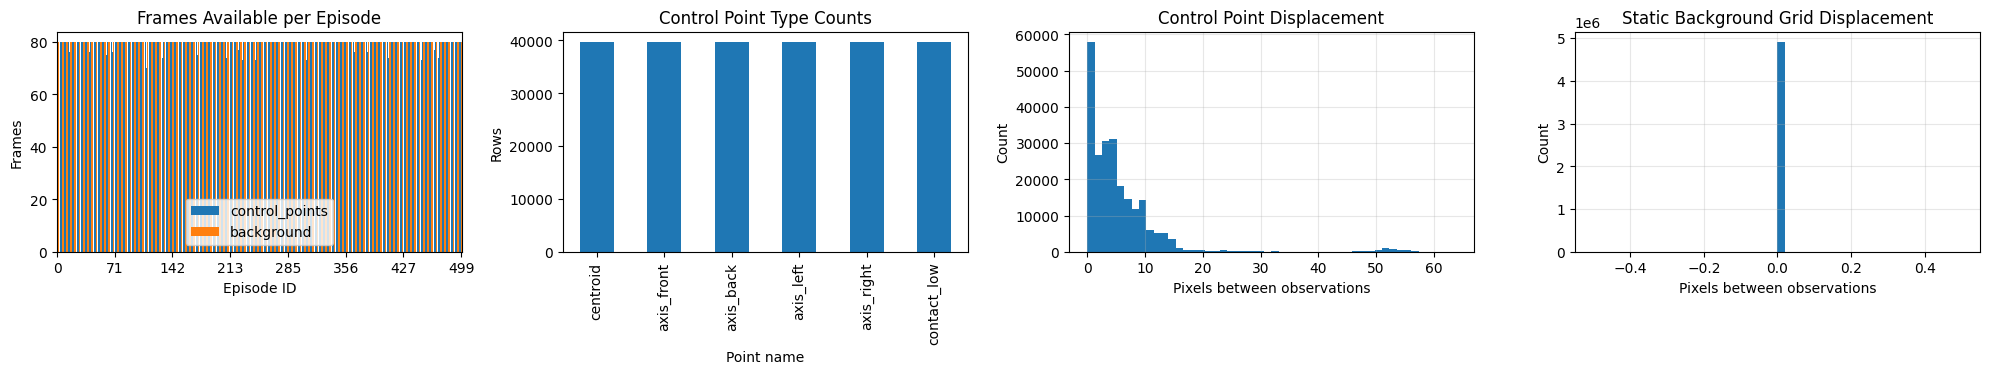

In [73]:
# Data Review - Visual Sanity Check + Save

cp_frames = lunar_cp_df.groupby("episode_id")["frame"].nunique()
bckg_frames = lunar_bckg_df.groupby("episode_id")["frame"].nunique()

cp_motion = lunar_cp_df.sort_values(
    ["episode_id", "track_id", "point_name", "frame"]
).copy()

motion_groups = cp_motion.groupby(
    ["episode_id", "track_id", "point_name"],
    observed=True,
)

cp_motion["dx"] = motion_groups["x"].diff()
cp_motion["dy"] = motion_groups["y"].diff()
cp_motion["speed"] = np.hypot(cp_motion["dx"], cp_motion["dy"])

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

frame_counts = pd.DataFrame({
    "control_points": cp_frames,
    "background": bckg_frames,
}).sort_index()

frame_counts.plot(kind="bar", ax=ax[0], width=0.9)

# Show at most 8 episode labels.
if len(frame_counts):
    tick_positions = np.unique(
        np.linspace(0, len(frame_counts) - 1, min(8, len(frame_counts)), dtype=int)
    )
    ax[0].set_xticks(tick_positions)
    ax[0].set_xticklabels(
        frame_counts.index[tick_positions],
        rotation=0,
    )

ax[0].set_title("Frames Available per Episode")
ax[0].set_xlabel("Episode ID")
ax[0].set_ylabel("Frames")

lunar_cp_df["point_name"].value_counts().reindex(
    CONTROL_POINT_NAMES, fill_value=0
).plot(kind="bar", ax=ax[1])

ax[1].set_title("Control Point Type Counts")
ax[1].set_xlabel("Point name")
ax[1].set_ylabel("Rows")

cp_speed_sample = cp_motion["speed"].replace(
    [np.inf, -np.inf], np.nan
).dropna()

ax[2].hist(cp_speed_sample, bins=50)
ax[2].set_title("Control Point Displacement")
ax[2].set_xlabel("Pixels between observations")
ax[2].set_ylabel("Count")
ax[2].grid(alpha=0.3)

bckg_speed_sample = lunar_bckg_df["speed"].replace(
    [np.inf, -np.inf], np.nan
).dropna()

ax[3].hist(bckg_speed_sample, bins=50)
ax[3].set_title("Static Background Grid Displacement")
ax[3].set_xlabel("Pixels between observations")
ax[3].set_ylabel("Count")
ax[3].grid(alpha=0.3)

plt.tight_layout()

data_review_plots_dir = PLOTS_DIR / "data_review"
data_review_plots_dir.mkdir(parents=True, exist_ok=True)

for extension in ("png", "pdf"):
    output_path = data_review_plots_dir / f"visual_sanity_check.{extension}"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print("saved:", output_path)

plt.show()

In [74]:
# Animate and save a random episode using only CP and background points.

common_episodes = np.intersect1d(
    lunar_cp_df["episode_id"].unique(),
    lunar_bckg_df_selected["episode_id"].unique(),
)
if len(common_episodes) == 0:
    raise ValueError("No shared episodes in CP and background data.")

episode_id = int(np.random.choice(common_episodes))

cp = lunar_cp_df.loc[lunar_cp_df["episode_id"] == episode_id].copy()
bg = lunar_bckg_df_selected.loc[
    lunar_bckg_df_selected["episode_id"] == episode_id
].copy()

frame_ids = np.union1d(cp["frame"].unique(), bg["frame"].unique())

if "observed" in cp.columns:
    cp = cp.loc[cp["observed"].eq(True)]
if "valid" in bg.columns:
    bg = bg.loc[bg["valid"].eq(True)]

cp = cp.dropna(subset=["x", "y"])
bg = bg.dropna(subset=["x", "y"])

# Infer canvas bounds from stored coordinates and object boxes.
xs = pd.concat([cp["x"], bg["x"]], ignore_index=True)
ys = pd.concat([cp["y"], bg["y"]], ignore_index=True)

if xs.empty:
    raise ValueError("This episode has no valid point coordinates.")

xmax = float(xs.max())
ymax = float(ys.max())
if "box_x2" in cp.columns and cp["box_x2"].notna().any():
    xmax = max(xmax, float(cp["box_x2"].max()))
if "box_y2" in cp.columns and cp["box_y2"].notna().any():
    ymax = max(ymax, float(cp["box_y2"].max()))

width = int(np.ceil(xmax)) + 30
height = int(np.ceil(ymax)) + 30

point_names = cp["point_name"].dropna().unique().tolist()
palette = plt.get_cmap("tab10")
colors = {
    name: tuple(int(c * 255) for c in palette(i % 10)[:3])
    for i, name in enumerate(point_names)
}

cp_groups = {f: group for f, group in cp.groupby("frame")}
bg_groups = {f: group for f, group in bg.groupby("frame")}

animation_frames = []

for frame_id in frame_ids:
    image = np.zeros((height, width, 3), dtype=np.uint8)

    background = bg_groups.get(frame_id)
    if background is not None:
        for row in background.itertuples(index=False):
            cv2.circle(
                image,
                (int(round(row.x)), int(round(row.y))),
                2, (70, 150, 100), -1,
            )

    control_points = cp_groups.get(frame_id)
    if control_points is not None:
        for row in control_points.itertuples(index=False):
            x, y = int(round(row.x)), int(round(row.y))
            color = colors[row.point_name]
            cv2.circle(image, (x, y), 3, color, -1)
            cv2.putText(
                image,
                str(row.point_name),
                (x + 5, max(12, y - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.3,
                color,
                1,
                cv2.LINE_AA,
            )

    cv2.putText(
        image,
        f"Episode {episode_id} | Frame {int(frame_id)}",
        (10, height - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )
    animation_frames.append(image)

# Save to plots/videos, then display the saved file.
GENERATED_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

points_video_path = save_video(
    np.stack(animation_frames),
    GENERATED_VIDEO_DIR / f"episode_{episode_id:04d}_background_and_cp_only.mp4",
    fps=10,
)

print("Episode:", episode_id)
print("Frames represented in the tables:", len(frame_ids))
print("saved:", points_video_path.resolve())

show_video_file(points_video_path, embed=True)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (570, 370) to (576, 384) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Episode: 158
Frames represented in the tables: 80
saved: /Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/episode_0158_background_and_cp_only.mp4


PosixPath('/Users/adriankazi/Desktop/Desktop - Adrian’s MacBook Pro/Action Inference/notebooks/artifacts/lunarlander_pretrain/plots/videos/episode_0158_background_and_cp_only.mp4')

In [75]:
lunar_bckg_df.head()

,episode_id,video_path,frame,background_point_id,x,y,dx,dy,speed,valid,prev_valid
0,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,20.0,20.0,NaN,NaN,NaN,True,False
1,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,1,60.0,20.0,NaN,NaN,NaN,True,False
2,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,2,100.0,20.0,NaN,NaN,NaN,True,False
3,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,3,140.0,20.0,NaN,NaN,NaN,True,False
4,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,4,180.0,20.0,NaN,NaN,NaN,True,False


In [76]:
lunar_cp_df.head()

,point_name,x,y,box_x1,box_y1,box_x2,box_y2,area,class_name,source,episode_id,video_path,frame,local_frame,track_id
0,centroid,299.810403,5.20302,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
1,axis_front,268.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
2,axis_back,331.000000,11.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
3,axis_left,271.000000,14.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0
4,axis_right,273.000000,0.00000,268,0,332,15,596,lunar_lander_agent,env_specific_color_geometry,0,/Users/adriankazi/Desktop/Desktop - Adrian’s M...,0,0,0


# Action Encoder

## Define Variables

### Control Points

In [77]:
# Action Encoder - Define Variables - Control Points

CONTROL_POINT_NAMES = [
    "centroid",
    "axis_front",
    "axis_back",
    "axis_left",
    "axis_right",
    "contact_low",
]

lunar_cp_df_reduced = lunar_cp_df[
    [
        "episode_id",
        "frame",
        "track_id",
        "point_name",
        "x",
        "y",
        "box_x1",
        "box_y1",
        "box_x2",
        "box_y2",
    ]
].copy()

lunar_cp_df_reduced["point_name"] = pd.Categorical(
    lunar_cp_df_reduced["point_name"],
    categories=CONTROL_POINT_NAMES,
    ordered=True,
)

lunar_cp_df_reduced = lunar_cp_df_reduced.sort_values(
    ["episode_id", "track_id", "frame", "point_name"]
).reset_index(drop=True)

print("lunar_cp_df_reduced shape:", lunar_cp_df_reduced.shape)
print(lunar_cp_df_reduced.head().to_string(index=False))

lunar_cp_df_reduced shape: (238158, 10)
 episode_id  frame  track_id point_name          x        y  box_x1  box_y1  box_x2  box_y2
          0      0         0   centroid 299.810403  5.20302     268       0     332      15
          0      0         0 axis_front 268.000000 11.00000     268       0     332      15
          0      0         0  axis_back 331.000000 11.00000     268       0     332      15
          0      0         0  axis_left 271.000000 14.00000     268       0     332      15
          0      0         0 axis_right 273.000000  0.00000     268       0     332      15


In [78]:
lunar_cp_df_reduced 

,episode_id,frame,track_id,point_name,x,y,box_x1,box_y1,box_x2,box_y2
0,0,0,0,centroid,299.810403,5.20302,268,0,332,15
1,0,0,0,axis_front,268.000000,11.00000,268,0,332,15
2,0,0,0,axis_back,331.000000,11.00000,268,0,332,15
3,0,0,0,axis_left,271.000000,14.00000,268,0,332,15
4,0,0,0,axis_right,273.000000,0.00000,268,0,332,15
...,...,...,...,...,...,...,...,...,...,...
238153,499,263,0,axis_front,246.000000,297.00000,246,264,306,301
238154,499,263,0,axis_back,305.000000,295.00000,246,264,306,301
238155,499,263,0,axis_left,249.000000,300.00000,246,264,306,301
238156,499,263,0,axis_right,262.000000,264.00000,246,264,306,301


### Visual Review

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_6681/1709708453.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for point_name, group in sample_cp.groupby("point_name"):


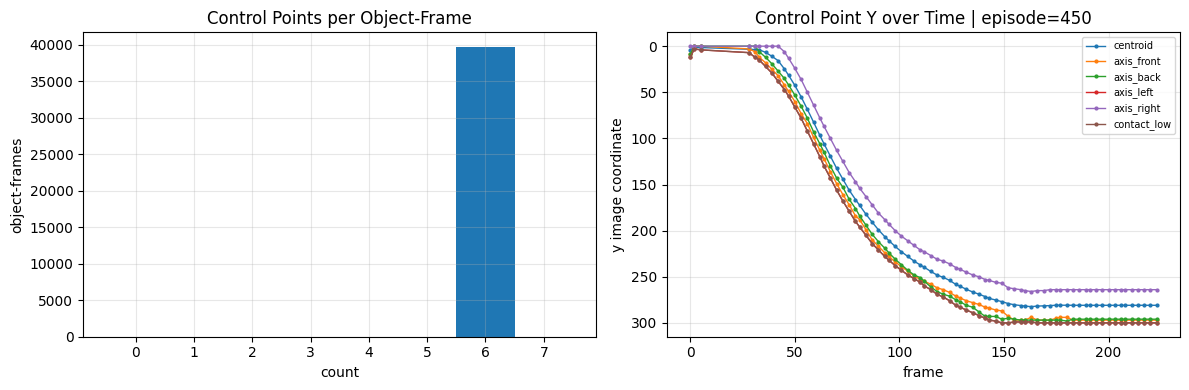

In [88]:
# Action Encoder - Control Point Variables - Visual Review

cp_reduced_counts = (
    lunar_cp_df_reduced
    .groupby(["episode_id", "frame", "track_id"])
    .size()
    .reset_index(name="n_control_points")
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cp_reduced_counts["n_control_points"], bins=np.arange(0, len(CONTROL_POINT_NAMES) + 3) - 0.5)
ax[0].set_title("Control Points per Object-Frame")
ax[0].set_xlabel("count")
ax[0].set_ylabel("object-frames")
ax[0].grid(alpha=0.3)

sample_episode_id = int(np.random.choice(sorted(lunar_cp_df_reduced["episode_id"].unique())))
sample_cp = lunar_cp_df_reduced[lunar_cp_df_reduced["episode_id"] == sample_episode_id]
for point_name, group in sample_cp.groupby("point_name"):
    ax[1].plot(group["frame"], group["y"], marker="o", markersize=2, linewidth=1, label=point_name)
ax[1].invert_yaxis()
ax[1].set_title(f"Control Point Y over Time | episode={sample_episode_id}")
ax[1].set_xlabel("frame")
ax[1].set_ylabel("y image coordinate")
ax[1].legend(fontsize=7)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Background

### Selection

In [89]:
# Action Encoder - Define Variables - Background

background_columns = [
    "episode_id",
    "frame",
    "background_point_id",
    "x",
    "y",
    "dx",
    "dy",
    "speed",
    "valid",
    "prev_valid",
]

lunar_bckg_df_reduced = lunar_bckg_df[background_columns].copy()
lunar_bckg_df_reduced = lunar_bckg_df_reduced.sort_values(
    ["episode_id", "frame", "background_point_id"]
).reset_index(drop=True)

# The background model already stores only sampled, valid points, so this is the
# motion-ready table consumed by action embedding cells below.
lunar_bckg_df_selected = lunar_bckg_df_reduced.copy()

print("lunar_bckg_df_reduced shape:", lunar_bckg_df_reduced.shape)
print("lunar_bckg_df_selected shape:", lunar_bckg_df_selected.shape)
print("episodes:", lunar_bckg_df_selected["episode_id"].nunique())
print(lunar_bckg_df_reduced.head().to_string(index=False))


lunar_bckg_df_reduced shape: (4969201, 10)
lunar_bckg_df_selected shape: (4969201, 10)
episodes: 500
 episode_id  frame  background_point_id     x    y  dx  dy  speed  valid  prev_valid
          0      0                    0  20.0 20.0 NaN NaN    NaN   True       False
          0      0                    1  60.0 20.0 NaN NaN    NaN   True       False
          0      0                    2 100.0 20.0 NaN NaN    NaN   True       False
          0      0                    3 140.0 20.0 NaN NaN    NaN   True       False
          0      0                    4 180.0 20.0 NaN NaN    NaN   True       False


### Visual Review

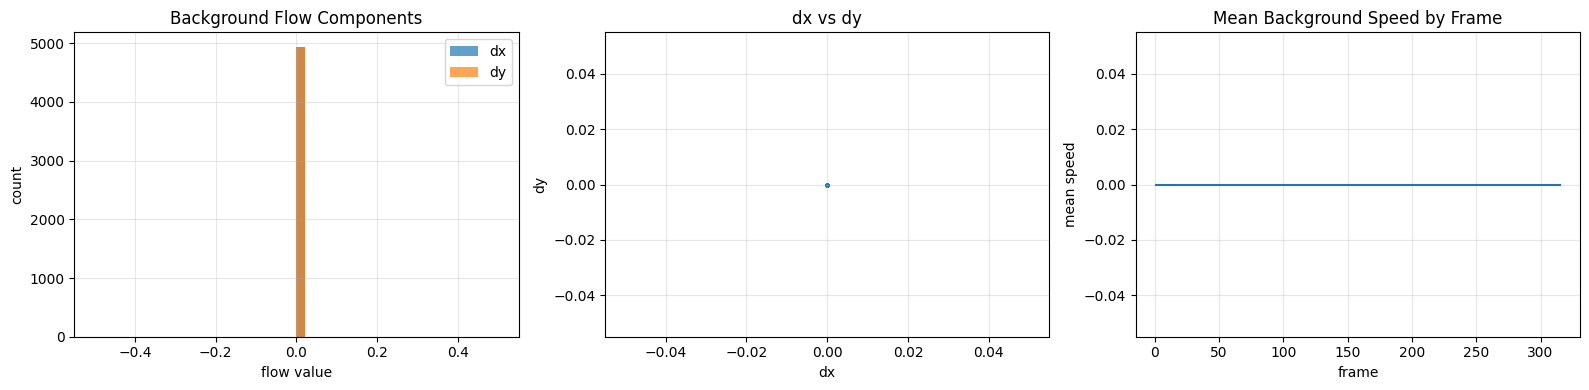

In [90]:
# Action Encoder - Background Variables - Visual Review

sample_bckg = lunar_bckg_df_reduced.sample(
    n=min(5000, len(lunar_bckg_df_reduced)),
    random_state=np.random.randint(0, 1_000_000),
)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(sample_bckg["dx"], bins=50, alpha=0.7, label="dx")
ax[0].hist(sample_bckg["dy"], bins=50, alpha=0.7, label="dy")
ax[0].set_title("Background Flow Components")
ax[0].set_xlabel("flow value")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].scatter(sample_bckg["dx"], sample_bckg["dy"], s=4, alpha=0.25)
ax[1].set_title("dx vs dy")
ax[1].set_xlabel("dx")
ax[1].set_ylabel("dy")
ax[1].grid(alpha=0.3)

speed_by_frame = lunar_bckg_df_reduced.groupby("frame")["speed"].mean()
ax[2].plot(speed_by_frame.index, speed_by_frame.values)
ax[2].set_title("Mean Background Speed by Frame")
ax[2].set_xlabel("frame")
ax[2].set_ylabel("mean speed")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
